In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

train = pd.read_csv("../data/raw/train(1).csv")
test  = pd.read_csv("../data/raw/test2.csv")

train.head()


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,9117000170,20150505T000000,268643,4,2.25,1810,9240,2.0,0,0,...,7,1810,0,1961,0,98055,47.4362,-122.187,1660,9240
1,6700390210,20140708T000000,245000,3,2.50,1600,2788,2.0,0,0,...,7,1600,0,1992,0,98031,47.4034,-122.187,1720,3605
2,7212660540,20150115T000000,200000,4,2.50,1720,8638,2.0,0,0,...,8,1720,0,1994,0,98003,47.2704,-122.313,1870,7455
3,8562780200,20150427T000000,352499,2,2.25,1240,705,2.0,0,0,...,7,1150,90,2009,0,98027,47.5321,-122.073,1240,750
4,7760400350,20141205T000000,232000,3,2.00,1280,13356,1.0,0,0,...,7,1280,0,1994,0,98042,47.3715,-122.074,1590,8071


In [4]:
train.shape

(16209, 21)

In [6]:
train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16209 entries, 0 to 16208
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             16209 non-null  int64  
 1   date           16209 non-null  object 
 2   price          16209 non-null  int64  
 3   bedrooms       16209 non-null  int64  
 4   bathrooms      16209 non-null  float64
 5   sqft_living    16209 non-null  int64  
 6   sqft_lot       16209 non-null  int64  
 7   floors         16209 non-null  float64
 8   waterfront     16209 non-null  int64  
 9   view           16209 non-null  int64  
 10  condition      16209 non-null  int64  
 11  grade          16209 non-null  int64  
 12  sqft_above     16209 non-null  int64  
 13  sqft_basement  16209 non-null  int64  
 14  yr_built       16209 non-null  int64  
 15  yr_renovated   16209 non-null  int64  
 16  zipcode        16209 non-null  int64  
 17  lat            16209 non-null  float64
 18  long  

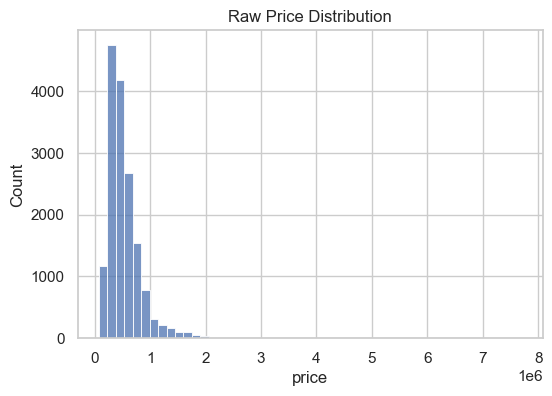

In [8]:
plt.figure(figsize=(6,4))
sns.histplot(train["price"], bins=50)
plt.title("Raw Price Distribution")
plt.show()


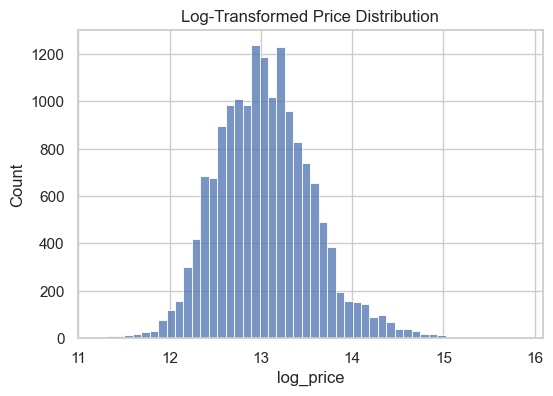

In [10]:
train["log_price"] = np.log1p(train["price"])

plt.figure(figsize=(6,4))
sns.histplot(train["log_price"], bins=50)
plt.title("Log-Transformed Price Distribution")
plt.show()


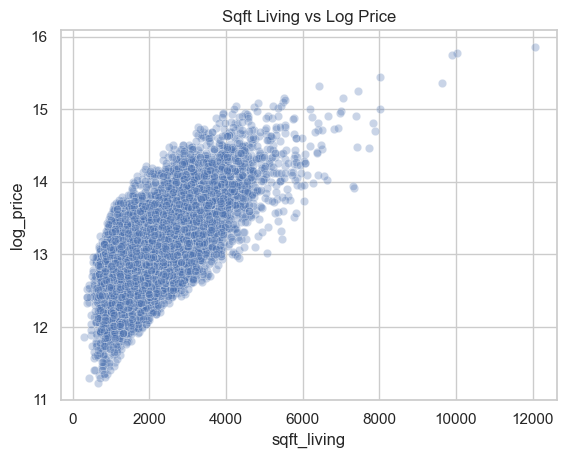

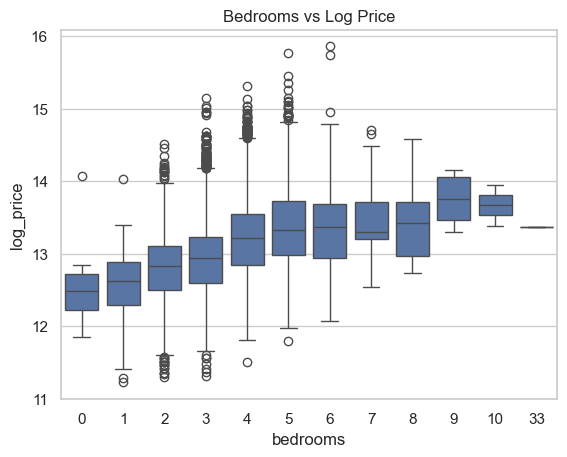

In [12]:
sns.scatterplot(
    x="sqft_living",
    y="log_price",
    data=train,
    alpha=0.3
)
plt.title("Sqft Living vs Log Price")
plt.show()

sns.boxplot(
    x="bedrooms",
    y="log_price",
    data=train
)
plt.title("Bedrooms vs Log Price")
plt.show()


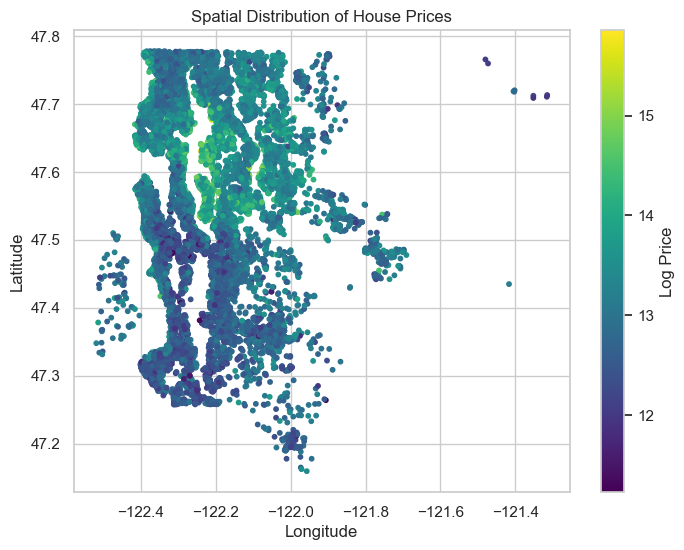

In [14]:
plt.figure(figsize=(8,6))
plt.scatter(
    train["long"],
    train["lat"],
    c=train["log_price"],
    cmap="viridis",
    s=10
)
plt.colorbar(label="Log Price")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial Distribution of House Prices")
plt.show()



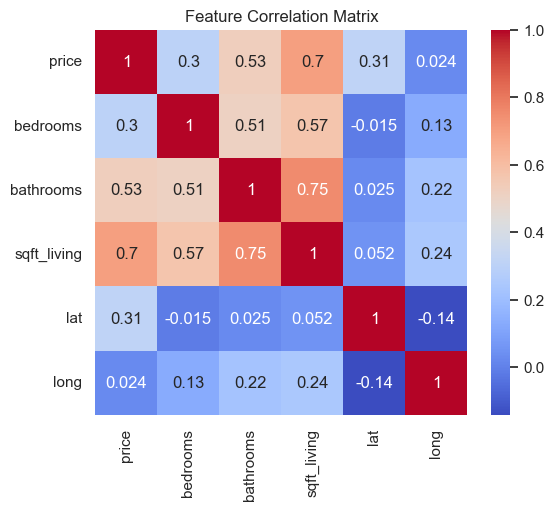

In [16]:
features = [
    "price",
    "bedrooms",
    "bathrooms",
    "sqft_living",
    "lat",
    "long"
]

plt.figure(figsize=(6,5))
sns.heatmap(
    train[features].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Feature Correlation Matrix")
plt.show()


## Key EDA Insights

1. House prices are highly right-skewed → log transform required.
2. Sqft_living shows strong correlation with price.
3. Latitude and longitude exhibit clear spatial clustering.
4. Certain geographic regions consistently command premium prices.
5. Tabular features alone cannot fully explain neighborhood-level variations.

These observations motivate the use of satellite imagery to capture environmental context.
